In [1]:
import os
import zipfile
from pathlib import Path
import random
import shutil
import math
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import transforms, models, datasets

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

from tqdm.notebook import tqdm

cwd = Path.cwd()
if (cwd / 'intel-image-classification').exists():
    DATA_DIR = (cwd / 'intel-image-classification').resolve()
elif (cwd.parent / 'intel-image-classification').exists():
    DATA_DIR = (cwd.parent / 'intel-image-classification').resolve()
else:
    DATA_DIR = Path('../intel-image-classification').resolve()

print("DATA_DIR:", DATA_DIR)
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

device = torch.device("cpu")  # lol


DATA_DIR: /Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/intel-image-classification


In [2]:
train_dir = DATA_DIR / 'seg_train/seg_train/'
test_dir  = DATA_DIR / 'seg_test/seg_test/'
pred_dir  = DATA_DIR / 'seg_pred/seg_pred/'

print("Using paths:")
print("  train_dir:", train_dir)
print("  test_dir: ", test_dir)
print("  pred_dir: ", pred_dir)

def build_df_from_imagefolder(root_dir):
    rows = []
    for class_dir in sorted([d for d in root_dir.iterdir() if d.is_dir()]):
        cls_name = class_dir.name
        for img in class_dir.glob("*"):
            if img.is_file():
                rows.append({"path": str(img), "label": None, "class": cls_name})
    df = pd.DataFrame(rows)
    classes = sorted(df['class'].unique())
    cls2idx = {c:i for i,c in enumerate(classes)}
    if not df.empty:
        df['label'] = df['class'].map(cls2idx)
    return df, classes, cls2idx

train_df, train_classes, train_cls2idx = build_df_from_imagefolder(train_dir)
test_df, test_classes, test_cls2idx = build_df_from_imagefolder(test_dir)

if test_df is not None and len(test_df)>0 and (not test_classes or len(test_classes)==0):
    test_classes = train_classes
    test_cls2idx = train_cls2idx

print("Train classes:", train_classes)
print("Train samples:", len(train_df) if isinstance(train_df, pd.DataFrame) else 0)
print("Test samples:", len(test_df) if isinstance(test_df, pd.DataFrame) else 0)

CLASS_NAMES = train_classes
NUM_CLASSES = len(CLASS_NAMES)
print("NUM_CLASSES =", NUM_CLASSES)


Using paths:
  train_dir: /Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/intel-image-classification/seg_train/seg_train
  test_dir:  /Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/intel-image-classification/seg_test/seg_test
  pred_dir:  /Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/intel-image-classification/seg_pred/seg_pred
Train classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train samples: 14034
Test samples: 3000
NUM_CLASSES = 6


6 classes


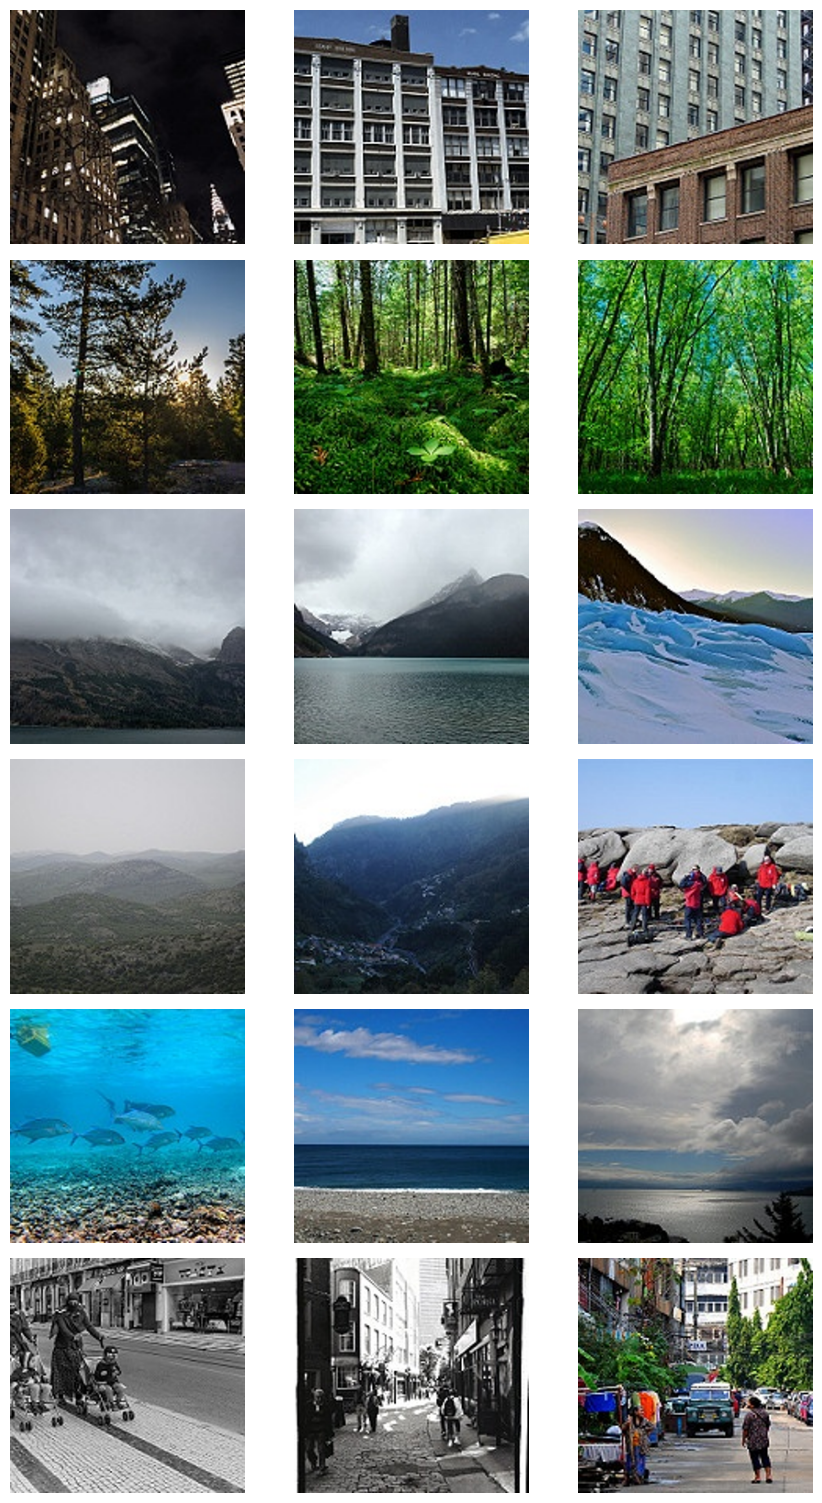

In [3]:
print(f"{NUM_CLASSES} classes")

n_examples = 3
fig_cols = n_examples
fig_rows = len(CLASS_NAMES)
plt.figure(figsize=(fig_cols*3, fig_rows*2.6))

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = train_dir / cls
    if not cls_dir.exists():
        sample_paths = train_df[train_df['class']==cls]['path'].tolist()[:n_examples]
    else:
        imgs = [p for p in cls_dir.glob("*") if p.is_file()]
        sample_paths = [str(p) for p in imgs[:n_examples]]
    for j in range(n_examples):
        idx = i * n_examples + j + 1
        plt.subplot(fig_rows, fig_cols, idx)
        if j < len(sample_paths):
            im = Image.open(sample_paths[j]).convert("RGB")
            plt.imshow(im.resize((256,256)))
            plt.axis('off')
            if j == 0:
                plt.ylabel(cls, fontsize=12)
        else:
            plt.text(0.5, 0.5, "No image", ha='center', va='center')
            plt.axis('off')

plt.tight_layout(rect=[0,0,1,0.97])


In [4]:
def check_images(df, verbose=False, report_every=100):
    broken = []
    if df is None or not isinstance(df, pd.DataFrame) or len(df) == 0:
        return broken
    paths = df['path'].tolist()
    total = len(paths)
    for i, p in enumerate(paths, 1):
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception as e:
            broken.append((p, str(e)))
        if verbose and (i % report_every == 0 or i == total):
            print(f"Checked {i}/{total} images — broken so far: {len(broken)}")
    return broken

broken_train = check_images(train_df) if len(train_df)>0 else []
broken_test  = check_images(test_df)  if isinstance(test_df, pd.DataFrame) and len(test_df)>0 else []

print("Broken train images:", len(broken_train))
print("Broken test images: ", len(broken_test))

move_broken = False
if move_broken and broken_train:
    broken_dir = DATA_DIR / "broken"
    broken_dir.mkdir(exist_ok=True)
    for p, _ in broken_train:
        try:
            shutil.move(p, broken_dir)
        except Exception:
            pass

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

denorm = transforms.Normalize(
    mean=[-m/s for m,s in zip(imagenet_mean, imagenet_std)],
    std=[1/s for s in imagenet_std]
)

full_dataset = datasets.ImageFolder(root=str(train_dir))
CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print("ImageFolder classes:", CLASS_NAMES)
n_total = len(full_dataset)
val_frac = 0.2
n_val = int(n_total * val_frac)
n_train = n_total - n_val
train_ds, val_ds = random_split(full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(RANDOM_SEED))
train_ds.dataset.transform = base_transform
val_ds.dataset.transform = base_transform

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"Created train_loader ({n_train} samples) and val_loader ({n_val} samples).")


test_loader = None
if test_dir.exists() and any(test_dir.iterdir()):
    test_dataset = datasets.ImageFolder(root=str(test_dir), transform=base_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Broken train images: 0
Broken test images:  0
ImageFolder classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Created train_loader (11228 samples) and val_loader (2806 samples).


   class_index  count class_name
0            0   2191  buildings
1            1   2271     forest
2            2   2404    glacier
3            3   2512   mountain
4            4   2274        sea
5            5   2382     street

Intermediate conclusions:
- Total classes: 6
- Largest class count: 2512
- Smallest class count: 2191
- Imbalance ratio (max/min): 1.15


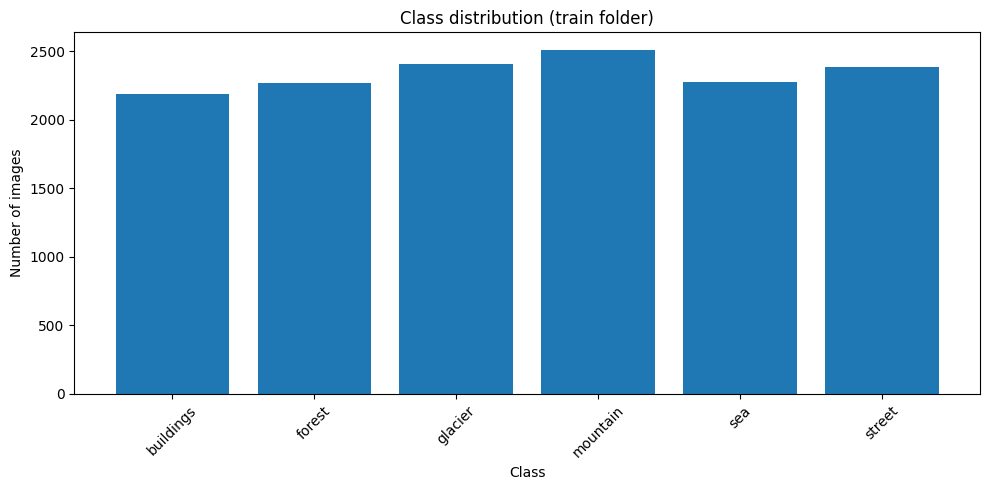

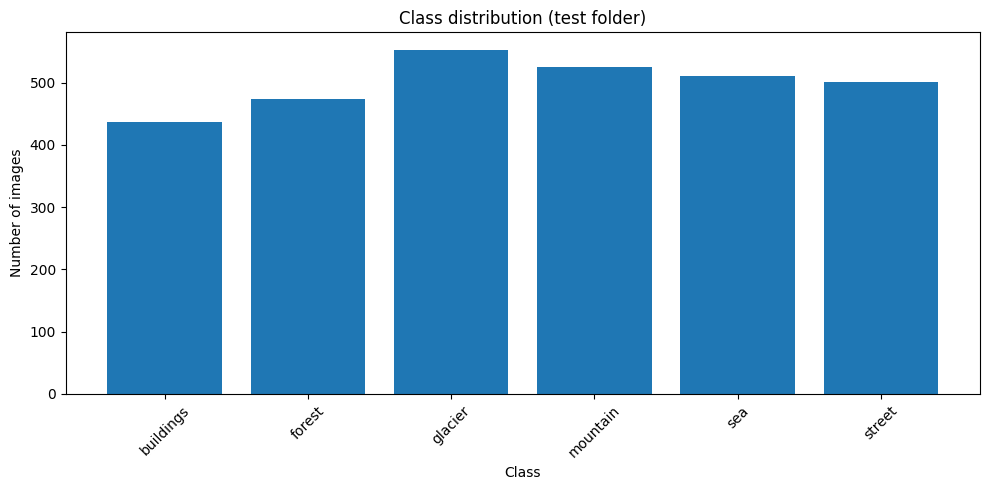

In [5]:
class_counts = Counter()
for _, label in full_dataset.samples:
    class_counts[label] += 1


counts_df = pd.DataFrame({
    "class_index": list(class_counts.keys()),
    "count": [class_counts[i] for i in sorted(class_counts.keys())]
})
counts_df['class_name'] = [full_dataset.classes[i] for i in counts_df['class_index']]
counts_df = counts_df.sort_values("class_index").reset_index(drop=True)

print(counts_df)

plt.figure(figsize=(10,5))
plt.bar(counts_df['class_name'], counts_df['count'])
plt.title("Class distribution (train folder)")
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.xticks(rotation=45)
plt.tight_layout()

if test_loader:
    test_counts = Counter([label for _, label in test_dataset.samples])
    test_df = pd.DataFrame({
        "class_name": [test_dataset.classes[i] for i in sorted(test_counts.keys())],
        "count": [test_counts[i] for i in sorted(test_counts.keys())]
    })
    plt.figure(figsize=(10,5))
    plt.bar(test_df['class_name'], test_df['count'])
    plt.title("Class distribution (test folder)")
    plt.ylabel("Number of images")
    plt.xlabel("Class")
    plt.xticks(rotation=45)
    plt.tight_layout()

print("\nIntermediate conclusions:")
print("- Total classes:", NUM_CLASSES)
print("- Largest class count:", counts_df['count'].max())
print("- Smallest class count:", counts_df['count'].min())
imbalance_ratio = counts_df['count'].max() / counts_df['count'].min() if counts_df['count'].min()>0 else float('inf')
print(f"- Imbalance ratio (max/min): {imbalance_ratio:.2f}")


In [6]:
train_augmentations = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02), 
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("Augmentations configured.")
print("""
- RandomResizedCrop: simulates different object scales and camera zoom.
- RandomHorizontalFlip / RandomRotation: adds geometric variation so model doesn't overfit to fixed orientations.
- ColorJitter: simulates different lighting and sensor conditions.
These help improve generalization to unseen real-world scenes.
""")


train_ds.dataset.transform = train_augmentations
val_ds.dataset.transform = val_transforms
if test_loader:
    test_dataset.transform = val_transforms

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
if test_loader:
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


Augmentations configured.

- RandomResizedCrop: simulates different object scales and camera zoom.
- RandomHorizontalFlip / RandomRotation: adds geometric variation so model doesn't overfit to fixed orientations.
- ColorJitter: simulates different lighting and sensor conditions.
These help improve generalization to unseen real-world scenes.



In [7]:
def get_model(model_name="resnet18", num_classes=NUM_CLASSES, pretrained=True):
    if model_name == "resnet18":
        model = models.resnet18(pretrained=pretrained)
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes)
    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(pretrained=pretrained)
        in_f = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_f, num_classes)
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=pretrained)
        in_f = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_f, num_classes)
    else:
        raise ValueError(f"Unknown model_name {model_name}")
    return model


def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += images.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def eval_model(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_targets = []
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += images.size(0)
            all_targets.extend(targets.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
    epoch_loss = running_loss / total if total>0 else 0.0
    epoch_acc = correct / total if total>0 else 0.0
    return epoch_loss, epoch_acc, np.array(all_targets), np.array(all_preds), np.array(all_probs)


Epoch 1/10


/Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10  train_loss=0.4455 train_acc=0.8446  val_loss=0.2800 val_acc=0.9002
Epoch 2/10
Epoch 2/10  train_loss=0.3356 train_acc=0.8854  val_loss=0.3785 val_acc=0.8664
Epoch 3/10
Epoch 3/10  train_loss=0.2773 train_acc=0.9014  val_loss=0.2441 val_acc=0.9170
Epoch 4/10
Epoch 4/10  train_loss=0.2541 train_acc=0.9155  val_loss=0.2648 val_acc=0.9130
Epoch 5/10
Epoch 5/10  train_loss=0.2375 train_acc=0.9188  val_loss=0.2767 val_acc=0.9070
Epoch 6/10
Epoch 6/10  train_loss=0.2202 train_acc=0.9239  val_loss=0.2799 val_acc=0.8981
Epoch 7/10
Epoch 7/10  train_loss=0.2049 train_acc=0.9297  val_loss=0.2925 val_acc=0.9098
Epoch 8/10
Epoch 8/10  train_loss=0.1051 train_acc=0.9662  val_loss=0.2274 val_acc=0.9269
Epoch 9/10
Epoch 9/10  train_loss=0.0700 train_acc=0.9767  val_loss=0.2479 val_acc=0.9262
Epoch 10/10
Epoch 10/10  train_loss=0.0494 train_acc=0.9848  val_loss=0.2564 val_acc=0.9277
Training finished. Best val acc: 0.9276550249465432


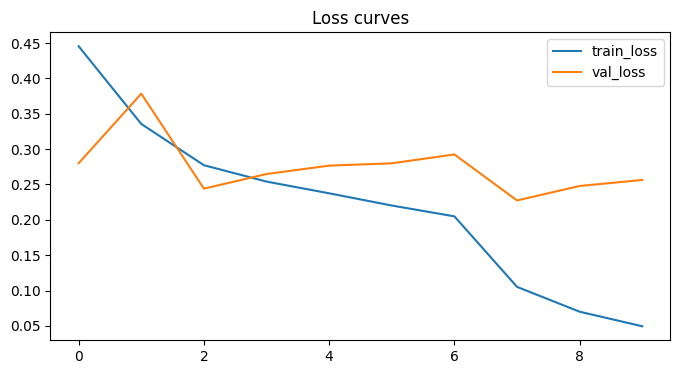

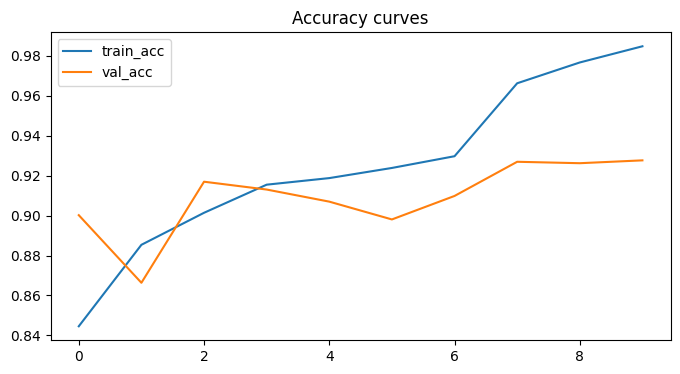

In [ ]:
model_name = "mobilenet_v2"   # "mobilenet_v2" "efficientnet_b0"
model = get_model(model_name=model_name, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

NUM_EPOCHS = 10

history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
best_val_acc = 0.0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _, _ = eval_model(model, val_loader, criterion)
    scheduler.step()
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  train_loss={train_loss:.4f} train_acc={train_acc:.4f}  val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k:v.cpu() for k,v in model.state_dict().items()} 

print("Training finished. Best val acc:", best_val_acc)

plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend(); plt.title("Loss curves")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend(); plt.title("Accuracy curves")
plt.show()


In [ ]:
from pathlib import Path
ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(exist_ok=True)
torch.save(best_model_state, ckpt_dir / "mobilenet_best_state.pth")

In [ ]:
torch.save(model.state_dict(), ckpt_dir / "mobilenet_current_state.pth")

In [ ]:
checkpoint = {
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict() if 'scheduler' in globals() else None,
    "best_val_acc": best_val_acc,
    "class_names": CLASS_NAMES,
    "history": history
}
torch.save(checkpoint, ckpt_dir / "mobilenet_full_checkpoint.pth")

# Run from here for 7 8 9

In [10]:
ckpt_dir = Path("checkpoints")
model_eval = get_model(model_name="mobilenet_v2", pretrained=False, num_classes=NUM_CLASSES)
model_eval.load_state_dict(torch.load(ckpt_dir / "mobilenet_best_state.pth", map_location=device))
model_eval = model_eval.to(device)
model_eval.eval()
print(f"Model loaded successfully from {ckpt_dir / 'mobilenet_best_state.pth'}")
print(f"Model architecture: MobileNetV2 with {NUM_CLASSES} classes")
print(f"Class names: {CLASS_NAMES}")

Model loaded successfully from checkpoints/mobilenet_best_state.pth
Model architecture: MobileNetV2 with 6 classes
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


/Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [11]:
def calculate_metrics(model, dataloader, dataset_name="Dataset"):
    """Calculate and print classification metrics"""
    model.eval()
    all_targets = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)
            
            all_targets.extend(targets.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            print('.', end='')
    
    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    precision_macro = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    recall_macro = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)  # macro averaging is better because of class imbalance
    print()
    print()
    print(f"{dataset_name} Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision_macro:.4f}")
    print(f"Recall: {recall_macro:.4f}")
    print(f"F1-Score (macro):  {f1_macro:.4f}")
    print()

    
    return all_targets, all_preds, all_probs

train_targets, train_preds, train_probs = calculate_metrics(model_eval, train_loader, "Training Set")

if test_loader:
    test_targets, test_preds, test_probs = calculate_metrics(model_eval, test_loader, "Test Set")
else:
    print("\nNo test loader available")
    test_targets, test_preds, test_probs = None, None, None

...............................................................................................................................................................................................................................................................................................................................................................

Training Set Metrics:
Accuracy: 0.9956
Precision: 0.9957
Recall: 0.9958
F1-Score (macro):  0.9957

..............................................................................................

Test Set Metrics:
Accuracy: 0.9237
Precision: 0.9255
Recall: 0.9254
F1-Score (macro):  0.9254



Training Set Metrics:
Accuracy: 0.9956
Precision: 0.9957
Recall: 0.9958
F1-Score (macro):  0.9957


Test Set Metrics:
Accuracy: 0.9237
Precision: 0.9255
Recall: 0.9254
F1-Score (macro):  0.9254

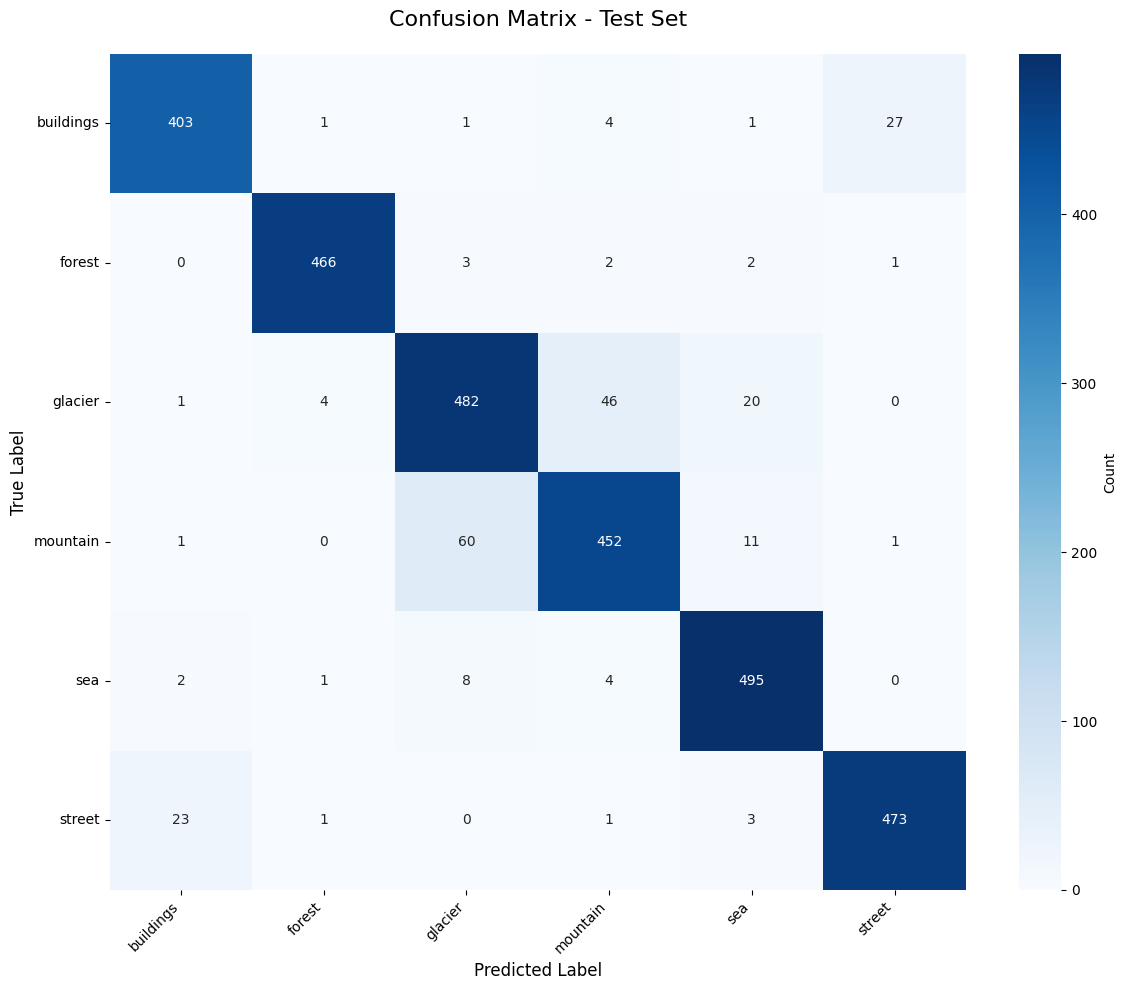


Per-class accuracy (Test Set):
  buildings   : 0.9222 (403/437)
  forest      : 0.9831 (466/474)
  glacier     : 0.8716 (482/553)
  mountain    : 0.8610 (452/525)
  sea         : 0.9706 (495/510)
  street      : 0.9441 (473/501)


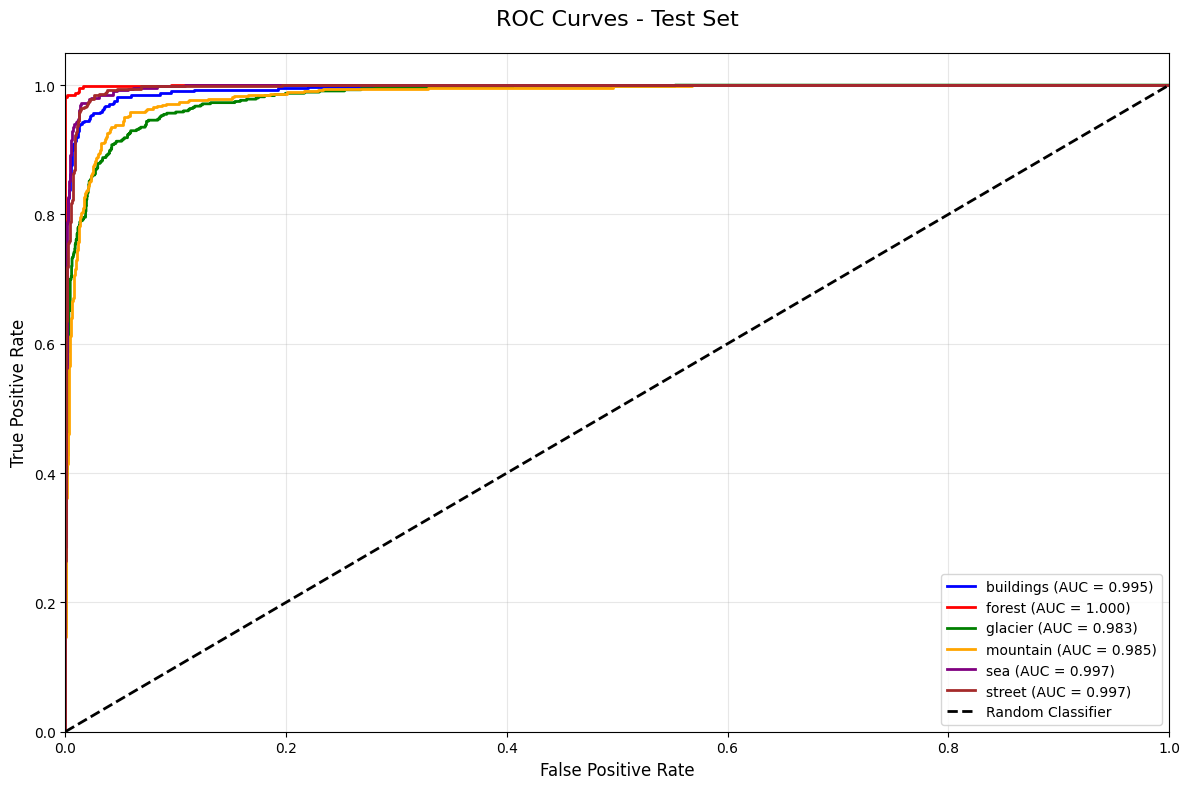


AUC Scores (Test Set):
  buildings   : 0.9949
  forest      : 0.9996
  glacier     : 0.9834
  mountain    : 0.9852
  sea         : 0.9973
  street      : 0.9965


In [12]:
import seaborn as sns
from itertools import cycle

def plot_confusion_matrix(targets, preds, class_names, dataset_name="Test"):
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {dataset_name} Set', fontsize=16, pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print(f"\nPer-class accuracy ({dataset_name} Set):")
    for i, cls in enumerate(class_names):
        cls_acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
        print(f"  {cls:12s}: {cls_acc:.4f} ({cm[i, i]}/{cm[i].sum()})")

def plot_roc_curves(targets, probs, class_names, dataset_name="Test"):
    targets_bin = label_binarize(targets, classes=range(len(class_names)))
    n_classes = len(class_names)
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(targets_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    

    plt.figure(figsize=(12, 8))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
    
    for i, color, cls in zip(range(n_classes), colors, class_names):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{cls} (AUC = {roc_auc[i]:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - {dataset_name} Set', fontsize=16, pad=20)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nAUC Scores ({dataset_name} Set):")
    for i, cls in enumerate(class_names):
        print(f"  {cls:12s}: {roc_auc[i]:.4f}")

# Plot for test set
if test_targets is not None:
    plot_confusion_matrix(test_targets, test_preds, CLASS_NAMES, "Test")
    plot_roc_curves(test_targets, test_probs, CLASS_NAMES, "Test")
else:
    print("No test data available for confusion matrix and ROC curves")

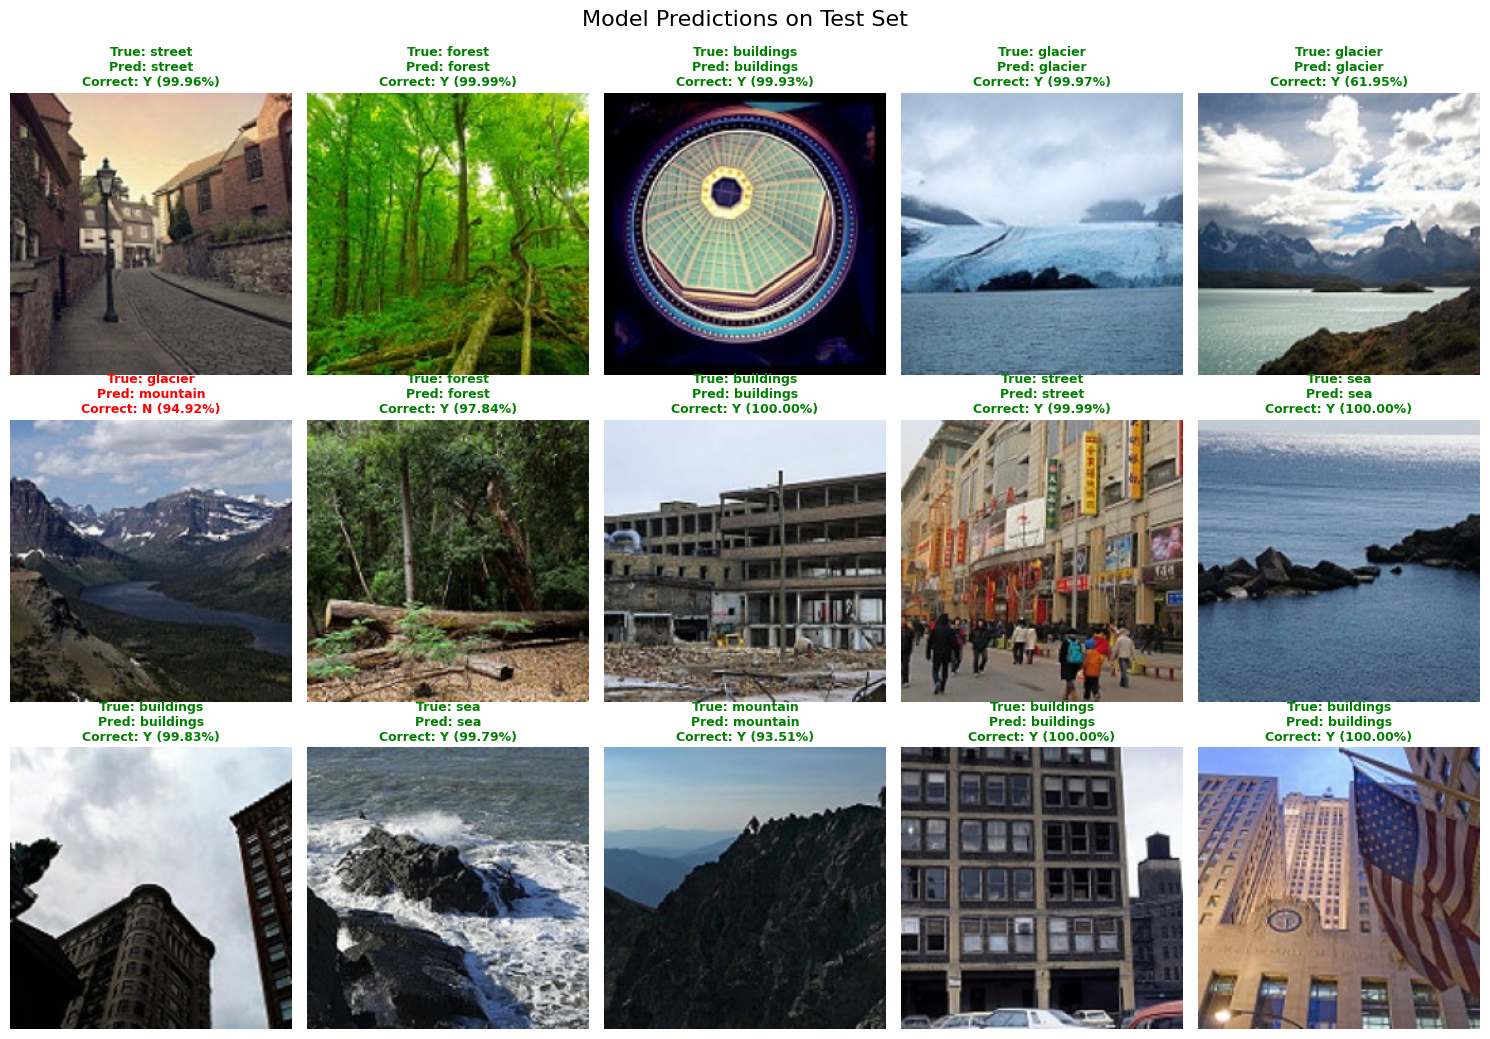

In [21]:
def visualize_predictions(model, dataset, class_names, n_images=15, cols=5):
    """Visualize model predictions on test images"""
    model.eval()

    indices = random.sample(range(len(dataset)), min(n_images, len(dataset)))
    
    rows = (n_images + cols - 1) // cols
    fig = plt.figure(figsize=(cols * 3, rows * 3.5))
    
    with torch.no_grad():
        for idx, sample_idx in enumerate(indices, 1):
            image, true_label = dataset[sample_idx]
            
            image_batch = image.unsqueeze(0).to(device)
            output = model(image_batch)
            probs = torch.softmax(output, dim=1)
            pred_label = probs.argmax(dim=1).item()
            confidence = probs[0, pred_label].item()
            
            img_display = image.cpu().clone()
            img_display = denorm(img_display)
            img_display = torch.clamp(img_display, 0, 1)
            img_display = img_display.permute(1, 2, 0).numpy()
            
            is_correct = "Y" if pred_label == true_label else "N"
            color = "green" if is_correct == "Y" else "red"
            
            ax = plt.subplot(rows, cols, idx)
            plt.imshow(img_display)
            plt.axis('off')
            
            title = f"True: {class_names[true_label]}\n"
            title += f"Pred: {class_names[pred_label]}\n"
            title += f"Correct: {is_correct} ({confidence:.2%})"
            
            plt.title(title, fontsize=9, color=color, weight='bold', pad=5)
    
    plt.suptitle('Model Predictions on Test Set', fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()

if test_loader:
    visualize_predictions(model_eval, test_dataset, CLASS_NAMES, n_images=15, cols=5)